In [4]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


## Simulate Data

In [5]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [6]:
c_params = [-2, -5,2,3]
n_users= 10000
num_features = 3
# train
x_obs_train = np.random.uniform(0, 1, size=(n_users, num_features))
probs_obs_train = sigmoid(c_params[0] + np.matmul(x_obs_train, c_params[1:]))
y_obs_train = np.random.binomial(1, probs_obs_train)
# test
x_obs_test = np.random.uniform(0, 1, size=(n_users, num_features))
probs_obs_test = sigmoid(c_params[0] + np.matmul(x_obs_test, c_params[1:]))
y_obs_test = np.random.binomial(1, probs_obs_test)



In [87]:
import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule, PyroSample
import torch.nn as nn


class BNN(PyroModule):
    def __init__(self, in_dim=num_features, out_dim=1, hid_dim=10, prior_scale=5.):
        super().__init__()

        self.activation = nn.Tanh()  # or nn.ReLU()
        self.layer1 = PyroModule[nn.Linear](in_dim, hid_dim)  # Input to hidden layer
        self.layer2 = PyroModule[nn.Linear](hid_dim, out_dim)  # Hidden to output layer

        # Set layer parameters as random variables
        self.layer1.weight = PyroSample(dist.Normal(0., prior_scale).expand([hid_dim, in_dim]).to_event(2))
        self.layer1.bias = PyroSample(dist.Normal(0., prior_scale).expand([hid_dim]).to_event(1))
        self.layer2.weight = PyroSample(dist.Normal(0., prior_scale).expand([out_dim, hid_dim]).to_event(2))
        self.layer2.bias = PyroSample(dist.Normal(0., prior_scale).expand([out_dim]).to_event(1))

    def forward(self, x, y=None):
        #x = x.reshape(-1, 1)
        x = self.activation(self.layer1(x))
        logits = self.layer2(x).squeeze()

        # Sampling model
        with pyro.plate("data", x.shape[0]):
            obs = pyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)
        return logits

In [8]:
## train
from pyro.infer import MCMC, NUTS
import torch

model = BNN(num_features=num_features)

# Set Pyro random seed
pyro.set_rng_seed(42)

# Define Hamiltonian Monte Carlo (HMC) kernel
# NUTS = "No-U-Turn Sampler" (https://arxiv.org/abs/1111.4246), gives HMC an adaptive step size
nuts_kernel = NUTS(model, jit_compile=False)  # jit_compile=True is faster but requires PyTorch 1.6+


# Define MCMC sampler, get 50 posterior samples
warmup_steps= 50
num_samples = 100
mcmc = MCMC(nuts_kernel, warmup_steps = warmup_steps, num_samples=num_samples)

# Convert data to PyTorch tensors
x_train = torch.from_numpy(x_obs_train).float()
y_train = torch.from_numpy(y_obs_train).float()

# Run MCMC
mcmc.run(x_train, y_train)


Sample: 100%|██████████| 150/150 [17:59,  7.19s/it, step size=3.21e-03, acc. prob=0.917]


In [9]:
mcmc


In [10]:
# Run on test data
from pyro.infer import Predictive
nuts_kernel = NUTS(model, jit_compile=False)

predictive = Predictive(model=model,posterior_samples=mcmc.get_samples())
x_train= torch.from_numpy(x_obs_train).float()
preds = predictive(x_train)



In [23]:
preds.keys()

dict_keys(['obs'])

In [13]:
model(x_train)

tensor([-16.0940, -16.1007, -18.4756,  ..., -15.8430, -18.4709, -18.9956])

In [137]:
probs_obs_train

array([0.01908635, 0.01231263, 0.03964141, ..., 0.51912833, 0.02702314,
       0.10006663])

In [138]:
preds['obs']

tensor([[1., 1., 1.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 1., 1.,  ..., 0., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.]])

In [70]:
preds.keys()

dict_keys(['obs'])

In [114]:
probs_obs_train

array([0.55594226, 0.01458209, 0.77648161, 0.06981956, 0.00552979,
       0.32425868, 0.1490961 , 0.26617932, 0.10803452, 0.03743513,
       0.01097042, 0.08409453, 0.21839818, 0.0779052 , 0.60421002,
       0.04192735, 0.18921966, 0.21212158, 0.05313735, 0.12859166,
       0.28608481, 0.16884862, 0.29388798, 0.00821293, 0.84862848,
       0.02022584, 0.2746254 , 0.01387055, 0.32833475, 0.11954804,
       0.75229192, 0.1439251 , 0.0245467 , 0.36184448, 0.54191661,
       0.46032313, 0.10709378, 0.81421737, 0.26637725, 0.61545344,
       0.03588097, 0.30723755, 0.01277061, 0.04510574, 0.71190058,
       0.38476382, 0.73355955, 0.20395123, 0.17920609, 0.02726526,
       0.00358459, 0.14807279, 0.04210685, 0.04703895, 0.02134775,
       0.00685842, 0.73313819, 0.40630401, 0.05709129, 0.16142628,
       0.3308587 , 0.0200188 , 0.03271189, 0.41789792, 0.01450289,
       0.59801337, 0.04975608, 0.645249  , 0.00893029, 0.00796295,
       0.19718297, 0.27185312, 0.45385246, 0.0382002 , 0.28143

In [14]:
preds['obs'].squeeze().mean(axis=0)

tensor([0.2400, 0.0800, 0.5500,  ..., 0.0300, 0.0400, 0.5800])

In [19]:
## check distributions:
import matplotlib.pyplot as plt
ind = 4
curr_pred = probs_obs_train[ind]

preds_from_model = preds['obs'].squeeze()[:,ind]
print(curr_pred)
print(preds_from_model.mean())

0.154484874437076
tensor(0.1900)


In [21]:
preds_from_model

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1.,
        1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0.,
        0., 0., 0., 1., 1., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 1., 0., 0.,
        0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 1., 1.,
        0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])

(array([81.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0., 19.]),
 array([0.        , 0.03333334, 0.06666667, 0.1       , 0.13333334,
        0.16666667, 0.2       , 0.23333333, 0.26666668, 0.30000001,
        0.33333334, 0.36666667, 0.40000001, 0.43333334, 0.46666667,
        0.5       , 0.53333336, 0.56666666, 0.60000002, 0.63333333,
        0.66666669, 0.69999999, 0.73333335, 0.76666665, 0.80000001,
        0.83333331, 0.86666667, 0.89999998, 0.93333334, 0.96666664,
        1.        ]),
 <BarContainer object of 30 artists>)

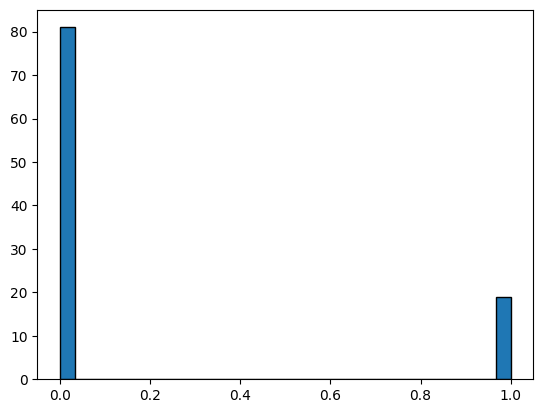

In [20]:
plt.hist(preds_from_model, bins=30, edgecolor='black')


# variational inference

## Using Pyro's SVI

In [88]:
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoDiagonalNormal
from tqdm.auto import trange
pyro.clear_param_store()

#model = BNN(hid_dim=10, n_hid_layers=5, prior_scale=5.)
deep_model = BNN(in_dim=num_features)
mean_field_guide = AutoDiagonalNormal(deep_model)
optimizer = pyro.optim.Adam({"lr": 0.01})

svi = SVI(deep_model, mean_field_guide, optimizer, loss=Trace_ELBO())
pyro.clear_param_store()

num_epochs = 1000
progress_bar = trange(num_epochs)
loss_list = []
for epoch in progress_bar:
    loss = svi.step(x_train, y_train)
    loss_list.append(loss)
    progress_bar.set_postfix(loss=f"{loss / x_train.shape[0]:.3f}")

100%|██████████| 1000/1000 [00:12<00:00, 78.97it/s, loss=0.399]


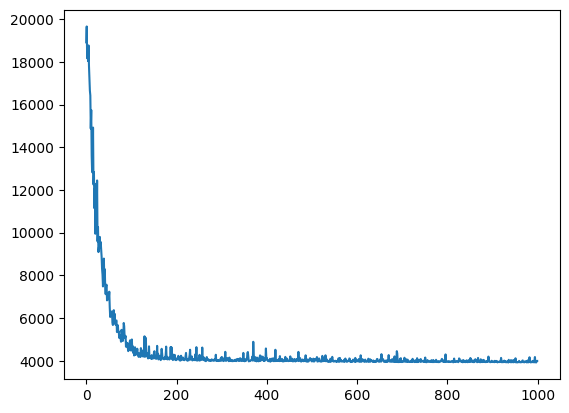

In [89]:
plt.figure()
plt.plot(loss_list)

## check parameters and logits

In [92]:
predictive = Predictive(deep_model, guide=mean_field_guide, num_samples=1000,
                        return_sites=("layer1.weight", "layer1.bias", "obs", "_RETURN"))
samples = predictive(x_train)
logits = samples['_RETURN'].squeeze()

0.25583996422750344
tensor(0.2199)
0.06673363345585184
tensor(0.0561)
0.5283628573270072
tensor(0.5860)
0.009280818185104504
tensor(0.0138)
0.154484874437076
tensor(0.1691)


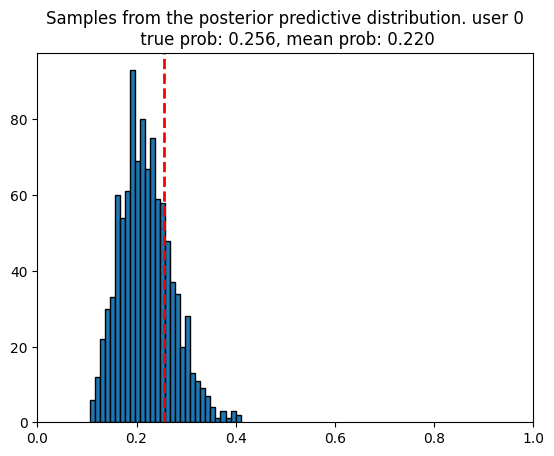

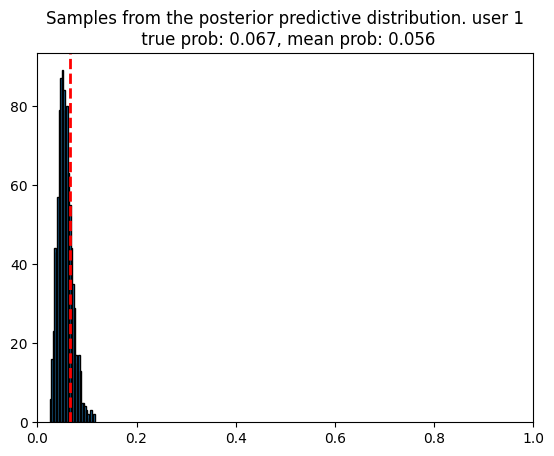

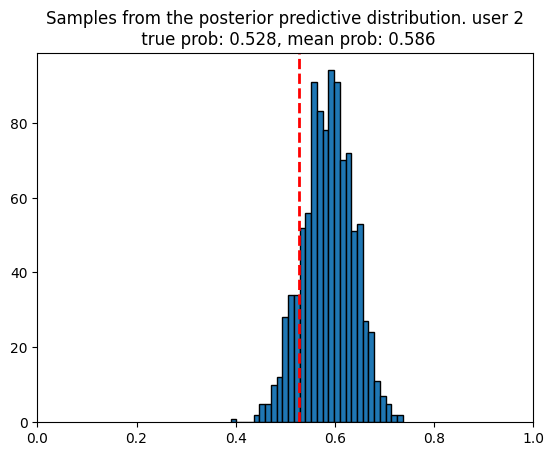

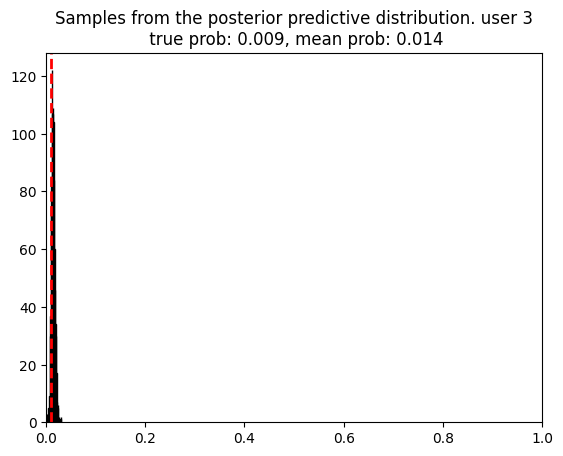

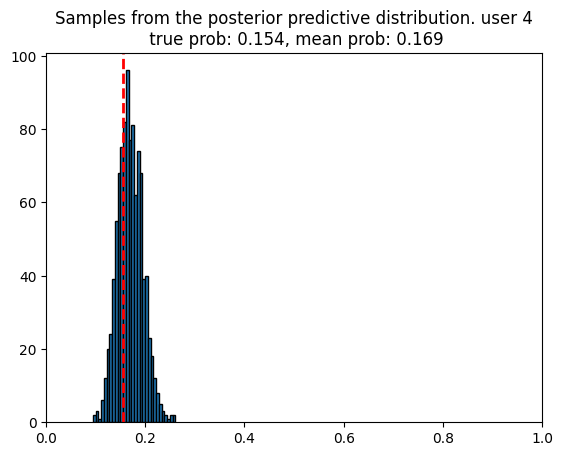

In [105]:
for ind in range(5):
    curr_pred = probs_obs_train[ind]

    preds_from_model = sigmoid(logits[:,ind])

    print(curr_pred)
    print(preds_from_model.mean())
    plt.figure()
    plt.hist(preds_from_model, bins=30, edgecolor='black')
    plt.axvline(x=curr_pred, color='r', linestyle='--', linewidth=2)
    plt.xlim(0, 1)
    plt.title(f'Samples from the posterior predictive distribution. user {ind}\n true prob: {curr_pred:.3f}, mean prob: {preds_from_model.mean():.3f}')


## check test data

In [103]:
x_test = torch.from_numpy(x_obs_test).float()

samples_test = predictive(x_test)
logits_test = samples_test['_RETURN'].squeeze()


0.005203239174938137
tensor(0.0159)
0.06519150846772767
tensor(0.0809)
0.03596639004266003
tensor(0.0566)
0.03683719722504371
tensor(0.0726)
0.22787928520593345
tensor(0.1755)
0.029527381138221648
tensor(0.0452)
0.013322867297224797
tensor(0.0157)
0.04697435345255502
tensor(0.0762)
0.0260794736898814
tensor(0.0566)
0.38636753152337455
tensor(0.3647)


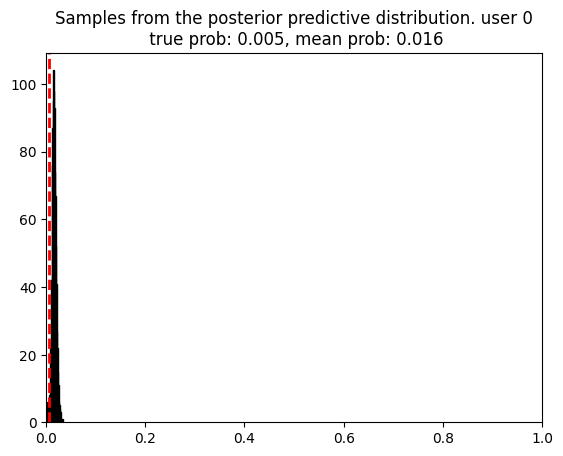

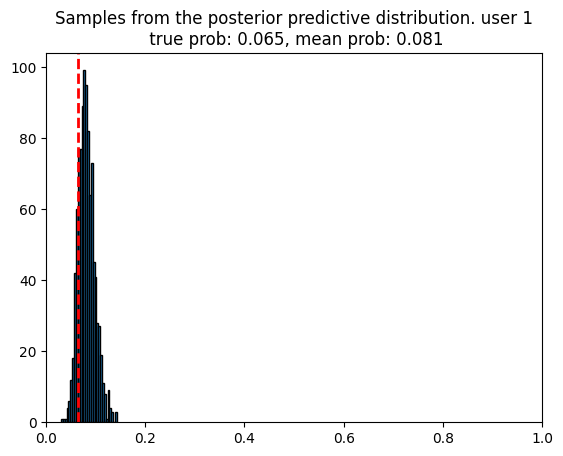

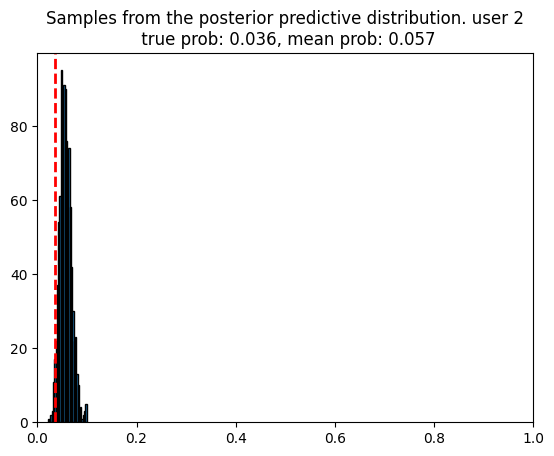

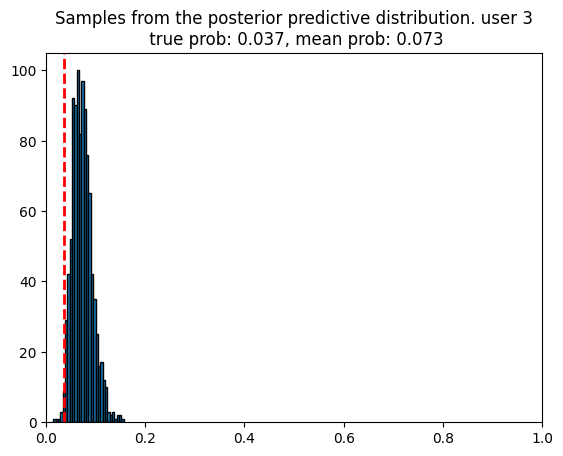

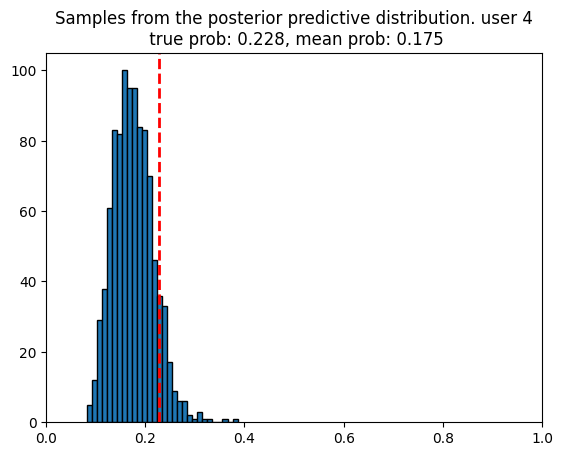

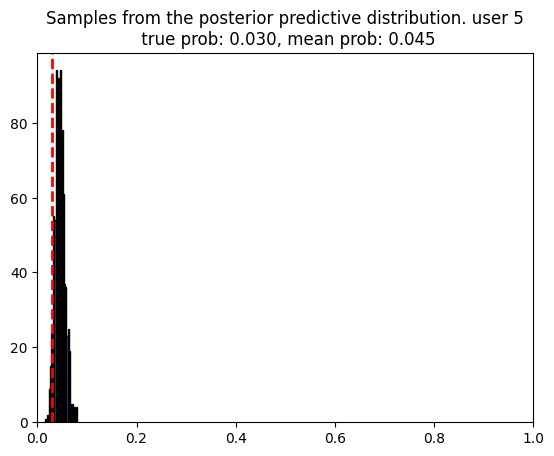

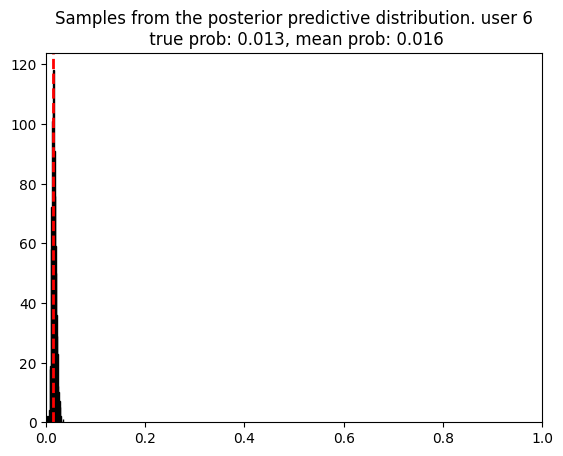

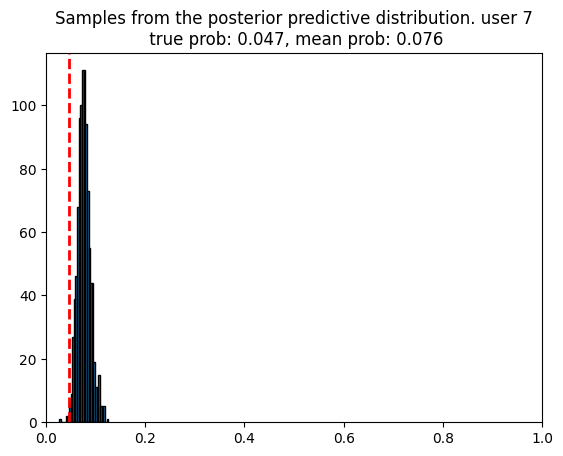

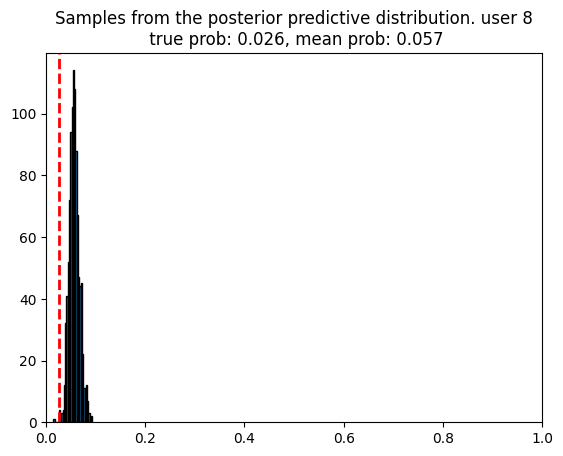

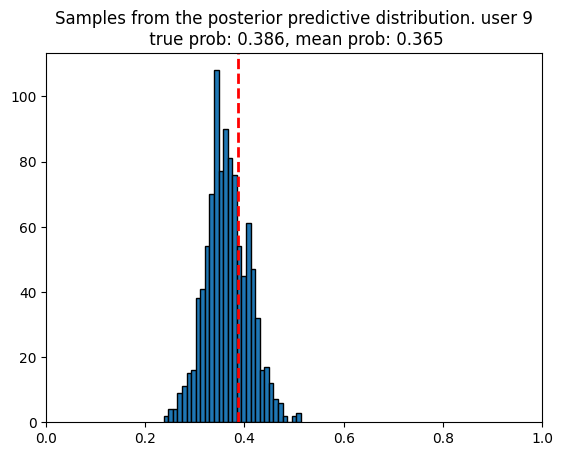

In [107]:
for ind in range(10):
    curr_pred = probs_obs_test[ind]

    preds_from_model = sigmoid(logits_test[:,ind])

    print(curr_pred)
    print(preds_from_model.mean())
    plt.figure()
    plt.hist(preds_from_model, bins=30, edgecolor='black')
    plt.axvline(x=curr_pred, color='r', linestyle='--', linewidth=2)
    plt.xlim(0, 1)
    plt.title(f'Samples from the posterior predictive distribution. user {ind}\n true prob: {curr_pred:.3f}, mean prob: {preds_from_model.mean():.3f}')


## Simple BNN

In [66]:
import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule, PyroSample
import torch.nn as nn


class Simple_BNN(PyroModule):
    def __init__(self, in_dim=num_features, out_dim=1, hid_dim=10, prior_scale=5.):
        super().__init__()

        self.layer1 = PyroModule[nn.Linear](in_dim, out_dim)

        # Set layer parameters as random variables
        self.layer1.weight = PyroSample(dist.Normal(0., prior_scale).expand([out_dim, in_dim, ]).to_event(2))
        self.layer1.bias = PyroSample(dist.Normal(0., prior_scale).expand([out_dim]).to_event(1))


    def forward(self, x, y=None):
        #x = x.reshape(-1, 1)
        logits = self.layer1(x).squeeze()

        # Sampling model
        with pyro.plate("data", x.shape[0]):
            obs = pyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)
        return logits

In [68]:
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoDiagonalNormal
from tqdm.auto import trange
pyro.clear_param_store()

#model = BNN(hid_dim=10, n_hid_layers=5, prior_scale=5.)
model = Simple_BNN(in_dim=num_features)
mean_field_guide = AutoDiagonalNormal(model)
optimizer = pyro.optim.Adam({"lr": 0.01})

svi = SVI(model, mean_field_guide, optimizer, loss=Trace_ELBO())
pyro.clear_param_store()

num_epochs = 10000
progress_bar = trange(num_epochs)
loss_list = []
for epoch in progress_bar:
    loss = svi.step(x_train, y_train)
    loss_list.append(loss)
    progress_bar.set_postfix(loss=f"{loss / x_train.shape[0]:.3f}")

100%|██████████| 10000/10000 [01:26<00:00, 116.12it/s, loss=0.375]


## check parameters

In [81]:
predictive = Predictive(model, guide=mean_field_guide, num_samples=1000,
                        return_sites=("layer1.weight","layer1.bias",  "obs", "_RETURN"))
samples = predictive(x_train)

In [85]:
samples['layer1.weight'].squeeze()

tensor([[-5.1278,  2.0692,  2.7831],
        [-4.9906,  2.1065,  2.7627],
        [-4.9230,  2.0463,  2.7396],
        ...,
        [-5.0156,  2.1743,  2.7812],
        [-5.0338,  2.0542,  2.8160],
        [-5.0444,  2.0242,  2.7726]])

In [78]:
mean_field_guide.get_posterior().mean

Parameter containing:
tensor([-5.0106,  2.0551,  2.7915, -1.8419], requires_grad=True)

In [79]:
mean_field_guide.get_posterior().stddev

tensor([0.0657, 0.0463, 0.0439, 0.0283], grad_fn=<SqrtBackward0>)